# Chapter 6: Triangulations

**Source orientation:** Armstrong, *Basic Topology*, Chapter 6, printed pp. 119-148; PDF pages 129-158. The source span covers finite simplicial complexes, barycentric subdivision, simplicial approximation, edge groups, orbit-space triangulations, and locally finite infinite complexes.

## Chapter Question

How can a topological space be replaced by finite combinatorial data without losing the information needed for maps, loops, quotients, and invariants?

The chapter's answer is triangulation. A triangulation is not just a picture made of triangles. It is a contract between geometry and combinatorics: points sit inside simplexes, maps can be approximated by vertex data after subdivision, loops can be read from edges, and quotient spaces can be rebuilt from vertex schemes. This notebook turns that contract into executable objects.

## Computational Translation Guide

| Book idea | Computational model used here | What we check |
| --- | --- | --- |
| Simplex, face, finite complex | facets closed under nonempty faces | face closure, allowed intersections, f-vectors |
| Polyhedron and carrier | each point belongs to one open simplex | boundary matrices and carrier-style examples |
| Barycentric subdivision | chains in the face poset | same polyhedron counts by Euler characteristic; smaller mesh |
| Simplicial approximation | vertex choices controlled by open stars | refined interval map passes local star tests |
| Edge group | edge paths modulo triangle moves | graph rank, triangle reduction, presentation data |
| Surface and orbit quotients | triangulated torus mesh plus quotient edge words | Euler characteristic, Betti numbers, watertight mesh |
| Infinite complexes | local finiteness instead of finite size | bounded vertex stars in a strip sample |

## Visual Storyboard Logic

The visuals move in the same order as the chapter. First we separate valid complexes from bad intersections. Then barycentric subdivision is drawn as a face-poset construction, not as arbitrary refinement. Simplicial approximation is shown by a map that fails before refinement and passes after star sizes shrink. Edge loops are tested on a graph and on filled triangles. Finally, quotient surfaces and infinite complexes show why triangulations are tools for spaces that are built or identified rather than merely drawn.

In [1]:
from __future__ import annotations

from collections import defaultdict
from itertools import combinations, permutations
from pathlib import Path
import json
import math
import sys

import gudhi
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
import trimesh


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        options = [candidate, candidate / "Basic-Topology"]
        for option in options:
            if (option / "00-book-index.ipynb").exists() and (option / "utils").exists():
                return option.resolve()
    raise RuntimeError("Could not find the Basic-Topology book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "chapter-06"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
TABLE_DIR = ARTIFACT_ROOT / "tables"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in (FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ARTIFACTS: list[Path] = []


def record(path: Path) -> Path:
    path = Path(path)
    if path not in ARTIFACTS:
        ARTIFACTS.append(path)
    return path


def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def write_json(data: dict, path: Path) -> Path:
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return record(path)


def write_csv(df: pd.DataFrame, path: Path) -> Path:
    df.to_csv(path, index=False)
    return record(path)


plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
{"book_root": BOOK_ROOT.name, "artifact_root": rel(ARTIFACT_ROOT)}

{'book_root': 'Basic-Topology', 'artifact_root': 'artifacts/chapter-06'}

## 1. Simplicial Complexes As Checkable Data

A finite complex can be stored by its top-dimensional simplexes, provided we remember that every face must also be present. The first computation builds the closure under faces, forms boundary matrices, and compares the resulting Betti numbers with Gudhi's independent simplicial-complex implementation.

The central invariant in this section is the Euler characteristic

```text
chi = number of vertices - number of edges + number of triangles - ...
```

For a disk it is 1, for a sphere it is 2, and for a torus it is 0. Subdivision may change all individual counts while leaving this alternating sum alone.

In [2]:
def canon(face):
    return tuple(sorted(face, key=repr))


def closure(facets):
    faces = set()
    for facet in facets:
        facet = canon(facet)
        for size in range(1, len(facet) + 1):
            for subface in combinations(facet, size):
                faces.add(canon(subface))
    return faces


def faces_by_dim(faces):
    by_dim = defaultdict(list)
    for face in faces:
        by_dim[len(face) - 1].append(face)
    return {dim: sorted(items, key=repr) for dim, items in by_dim.items()}


def f_vector(faces):
    by_dim = faces_by_dim(faces)
    if not by_dim:
        return []
    return [len(by_dim.get(dim, [])) for dim in range(max(by_dim) + 1)]


def euler_characteristic(faces):
    return sum(((-1) ** dim) * count for dim, count in enumerate(f_vector(faces)))


def boundary_matrix(faces, dim):
    by_dim = faces_by_dim(faces)
    domain = by_dim.get(dim, [])
    codomain = by_dim.get(dim - 1, [])
    matrix = sp.zeros(len(codomain), len(domain))
    if not domain or not codomain:
        return matrix
    row_index = {face: idx for idx, face in enumerate(codomain)}
    for col, simplex in enumerate(domain):
        vertices = list(simplex)
        for i in range(len(vertices)):
            face = canon(vertices[:i] + vertices[i + 1:])
            matrix[row_index[face], col] = (-1) ** i
    return matrix


def betti_over_q(faces, max_dim=None):
    by_dim = faces_by_dim(faces)
    if max_dim is None:
        max_dim = max(by_dim) if by_dim else 0
    ranks = {dim: boundary_matrix(faces, dim).rank() for dim in range(1, max_dim + 2)}
    betti = []
    for dim in range(max_dim + 1):
        chain_rank = len(by_dim.get(dim, []))
        betti.append(int(chain_rank - ranks.get(dim, 0) - ranks.get(dim + 1, 0)))
    return betti


def boundary_square_zero(faces):
    by_dim = faces_by_dim(faces)
    max_dim = max(by_dim) if by_dim else 0
    checks = {}
    for dim in range(1, max_dim):
        lower = boundary_matrix(faces, dim)
        upper = boundary_matrix(faces, dim + 1)
        product = lower * upper
        checks[f"d{dim}_after_d{dim + 1}"] = bool(product == sp.zeros(*product.shape))
    return checks


def gudhi_betti(faces):
    vertices = sorted({vertex for face in faces for vertex in face}, key=repr)
    relabel = {vertex: idx for idx, vertex in enumerate(vertices)}
    tree = gudhi.SimplexTree()
    for face in sorted(faces, key=lambda item: (len(item), repr(item))):
        tree.insert([relabel[vertex] for vertex in face])
    tree.compute_persistence(persistence_dim_max=True)
    return [int(value) for value in tree.betti_numbers()]


def periodic_torus_facets(nx: int, ny: int):
    if nx < 3 or ny < 3:
        raise ValueError("Use at least a 3 by 3 periodic grid to avoid collapsed triangles")

    def idx(i, j):
        return (i % nx) * ny + (j % ny)

    facets = []
    for i in range(nx):
        for j in range(ny):
            facets.append((idx(i, j), idx(i + 1, j), idx(i + 1, j + 1)))
            facets.append((idx(i, j), idx(i + 1, j + 1), idx(i, j + 1)))
    return facets


triangle_disk = closure([(0, 1, 2)])
tetrahedron_sphere = closure([(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)])
torus_4x4 = closure(periodic_torus_facets(4, 4))

complexes = {
    "one filled triangle": triangle_disk,
    "tetrahedron boundary sphere": tetrahedron_sphere,
    "periodic 4x4 torus triangulation": torus_4x4,
}

rows = []
for name, faces in complexes.items():
    rows.append(
        {
            "complex": name,
            "f_vector": str(f_vector(faces)),
            "chi": int(euler_characteristic(faces)),
            "betti_Q": str(betti_over_q(faces, max_dim=2)),
            "betti_gudhi": str(gudhi_betti(faces)),
            "boundary_squared_zero": all(boundary_square_zero(faces).values()) if boundary_square_zero(faces) else True,
        }
    )

invariant_df = pd.DataFrame(rows)
write_csv(invariant_df, TABLE_DIR / "simplicial-invariants.csv")
write_json({"rows": rows}, CHECK_DIR / "simplicial-invariants.json")
invariant_df

,complex,f_vector,chi,betti_Q,betti_gudhi,boundary_squared_zero
0,one filled triangle,"[3, 3, 1]",1,"[1, 0, 0]","[1, 0, 0]",True
1,tetrahedron boundary sphere,"[4, 6, 4]",2,"[1, 0, 1]","[1, 0, 1]",True
2,periodic 4x4 torus triangulation,"[16, 48, 32]",0,"[1, 2, 1]","[1, 2, 1]",True


The table is deliberately small. It tells us which part of the drawing is expendable and which part is not: coordinates can move, but the face relation and the boundary maps determine the invariant data. The torus row also anticipates the quotient section: a rectangular grid with opposite sides identified becomes a closed triangulated surface with `chi = 0` and first Betti number 2.

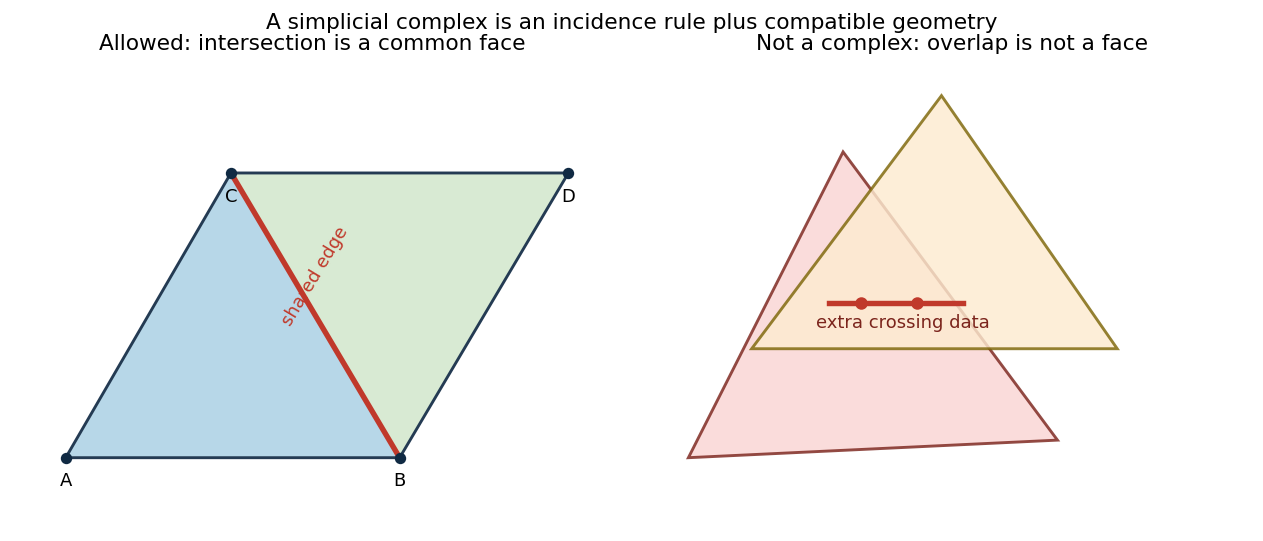

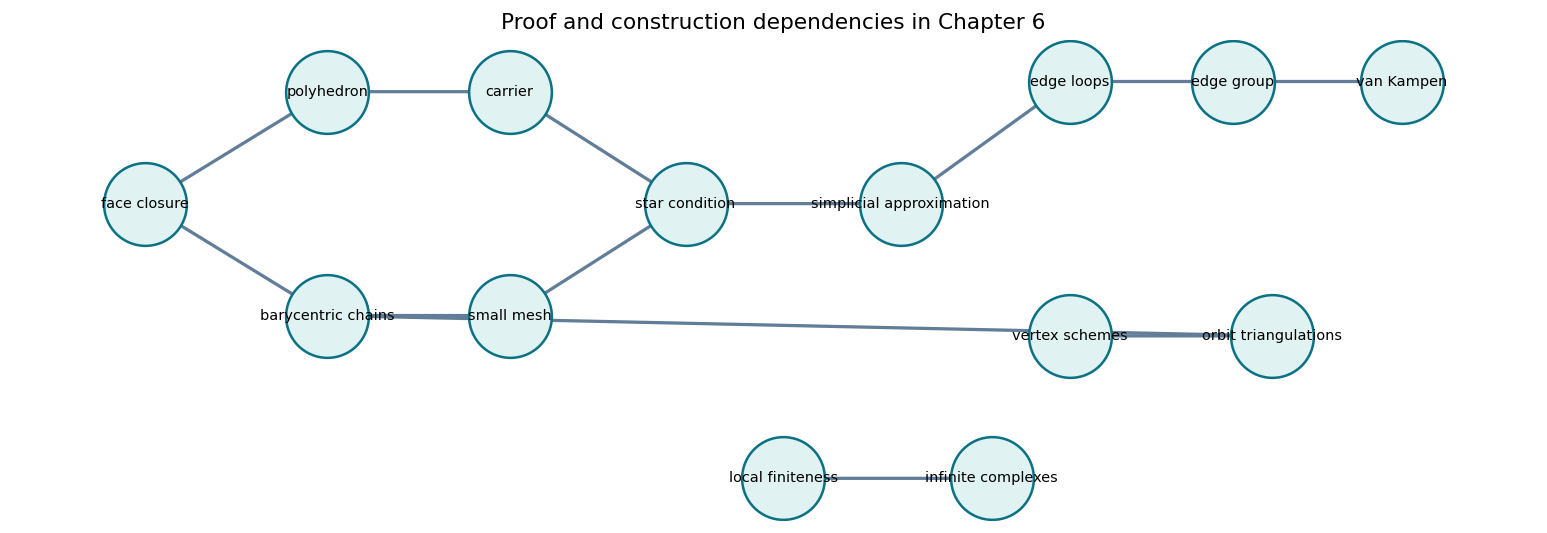

In [3]:
def draw_valid_invalid_complex(path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    valid = {"A": np.array([0.05, 0.05]), "B": np.array([1.0, 0.05]), "C": np.array([0.52, 0.86]), "D": np.array([1.48, 0.86])}
    for tri, color in zip([("A", "B", "C"), ("B", "D", "C")], ["#b7d7e8", "#d8ead3"]):
        axes[0].add_patch(Polygon([valid[v] for v in tri], closed=True, facecolor=color, edgecolor="#243b53", linewidth=1.6))
    axes[0].plot(*zip(valid["B"], valid["C"]), color="#c0392b", linewidth=3)
    for label, point in valid.items():
        axes[0].scatter(*point, color="#102a43", s=28, zorder=5)
        axes[0].text(point[0], point[1] - 0.08, label, ha="center")
    axes[0].set_title("Allowed: intersection is a common face")
    axes[0].text(0.76, 0.43, "shared edge", color="#c0392b", rotation=59, ha="center")

    bad_1 = np.array([[0.0, 0.05], [1.05, 0.1], [0.44, 0.92]])
    bad_2 = np.array([[0.18, 0.36], [1.22, 0.36], [0.72, 1.08]])
    axes[1].add_patch(Polygon(bad_1, closed=True, facecolor="#f9d5d3", edgecolor="#7b241c", linewidth=1.6, alpha=0.82))
    axes[1].add_patch(Polygon(bad_2, closed=True, facecolor="#fdebd0", edgecolor="#7d6608", linewidth=1.6, alpha=0.82))
    axes[1].scatter([0.49, 0.65], [0.49, 0.49], color="#c0392b", s=35, zorder=5)
    axes[1].plot([0.40, 0.78], [0.49, 0.49], color="#c0392b", linewidth=3)
    axes[1].set_title("Not a complex: overlap is not a face")
    axes[1].text(0.61, 0.42, "extra crossing data", color="#7b241c", ha="center")
    for ax in axes:
        ax.set_aspect("equal")
        ax.set_xlim(-0.1, 1.6)
        ax.set_ylim(-0.15, 1.18)
        ax.axis("off")
    fig.suptitle("A simplicial complex is an incidence rule plus compatible geometry", y=0.98)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return record(path)


def draw_dependency_map(path: Path):
    graph = nx.DiGraph()
    graph.add_edges_from([
        ("face closure", "polyhedron"), ("polyhedron", "carrier"), ("face closure", "barycentric chains"),
        ("barycentric chains", "small mesh"), ("small mesh", "star condition"), ("carrier", "star condition"),
        ("star condition", "simplicial approximation"), ("simplicial approximation", "edge loops"),
        ("edge loops", "edge group"), ("edge group", "van Kampen"), ("vertex schemes", "orbit triangulations"),
        ("barycentric chains", "orbit triangulations"), ("local finiteness", "infinite complexes"),
    ])
    pos = {
        "face closure": (0.0, 2.0), "polyhedron": (1.4, 2.55), "carrier": (2.8, 2.55),
        "barycentric chains": (1.4, 1.45), "small mesh": (2.8, 1.45), "star condition": (4.15, 2.0),
        "simplicial approximation": (5.8, 2.0), "edge loops": (7.1, 2.6), "edge group": (8.35, 2.6),
        "van Kampen": (9.65, 2.6), "vertex schemes": (7.1, 1.35), "orbit triangulations": (8.65, 1.35),
        "local finiteness": (4.9, 0.65), "infinite complexes": (6.5, 0.65),
    }
    fig, ax = plt.subplots(figsize=(12, 4.2))
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#617d98", width=1.8)
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=2100, node_color="#e0f2f1", edgecolors="#0b7285", linewidths=1.4)
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=8)
    ax.set_title("Proof and construction dependencies in Chapter 6")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return record(path)

incidence_path = draw_valid_invalid_complex(FIG_DIR / "simplicial-complex-incidence.png")
dependency_path = draw_dependency_map(FIG_DIR / "concept-dependency-map.png")
for path in (incidence_path, dependency_path):
    assert_artifact(path, min_bytes=1024)
    display_artifact(path, width=820)

## 2. Barycentric Subdivision: Refinement From Chains Of Faces

Barycentric subdivision adds one vertex for each nonempty face and then connects barycentres only when the corresponding faces form a chain. For a triangle, a maximal chain has the form

```text
vertex < edge < triangle
```

so each small triangle remembers which original vertex, which original edge, and which original face produced it. This is why subdivision is controlled enough for proofs: it shrinks mesh while preserving the same underlying polyhedron.

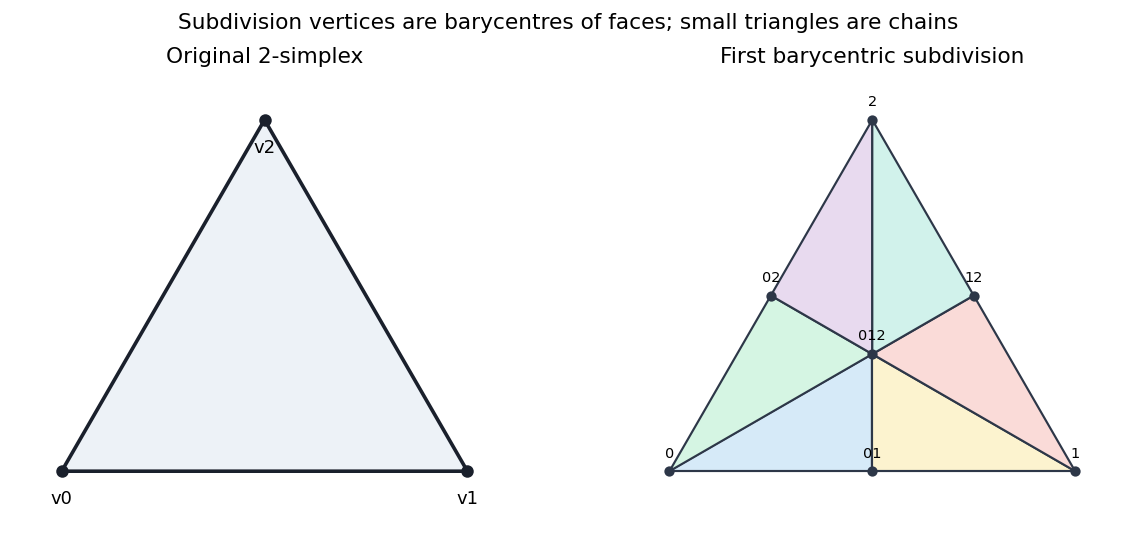

{'original_f_vector': [3, 3, 1],
 'subdivision_f_vector': [7, 12, 6],
 'original_chi': 1,
 'subdivision_chi': 1,
 'old_mesh': 1.0,
 'new_mesh': 0.5773502691896257,
 'mesh_ratio': 0.5773502691896257,
 'expected_ratio_bound_for_dimension_2': 0.6666666666666666}

In [4]:
def barycentric_subdivision_facets(facets):
    new_facets = set()
    for facet in facets:
        facet = canon(facet)
        for order in permutations(facet):
            chain = []
            for size in range(1, len(order) + 1):
                chain.append(canon(order[:size]))
            new_facets.add(tuple(chain))
    return sorted(new_facets, key=repr)


def barycenter(face, coords):
    return np.mean([coords[v] for v in face], axis=0)


def mesh_length_from_edges(edges, coords):
    lengths = []
    for a, b in edges:
        lengths.append(float(np.linalg.norm(coords[a] - coords[b])))
    return max(lengths) if lengths else 0.0

triangle_coords = {0: np.array([0.0, 0.0]), 1: np.array([1.0, 0.0]), 2: np.array([0.5, math.sqrt(3) / 2])}
triangle_facets = [(0, 1, 2)]
subdivision_facets = barycentric_subdivision_facets(triangle_facets)
subdivision_faces = closure(subdivision_facets)
subdivision_coords = {face: barycenter(face, triangle_coords) for face in {v for facet in subdivision_facets for v in facet}}

original_edges = faces_by_dim(triangle_disk)[1]
subdivision_edges = faces_by_dim(subdivision_faces)[1]
old_mesh = mesh_length_from_edges(original_edges, triangle_coords)
new_mesh = mesh_length_from_edges(subdivision_edges, subdivision_coords)
mesh_ratio = new_mesh / old_mesh

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
axes[0].add_patch(Polygon([triangle_coords[i] for i in (0, 1, 2)], closed=True, facecolor="#edf2f7", edgecolor="#1a202c", linewidth=2))
for i, point in triangle_coords.items():
    axes[0].scatter(*point, color="#1a202c", s=35)
    axes[0].text(point[0], point[1] - 0.08, f"v{i}", ha="center")
axes[0].set_title("Original 2-simplex")

colors = ["#d6eaf8", "#d5f5e3", "#fcf3cf", "#fadbd8", "#e8daef", "#d1f2eb"]
for idx, facet in enumerate(subdivision_facets):
    points = [subdivision_coords[face] for face in facet]
    axes[1].add_patch(Polygon(points, closed=True, facecolor=colors[idx % len(colors)], edgecolor="#2d3748", linewidth=1.2))
for face, point in subdivision_coords.items():
    axes[1].scatter(*point, color="#2d3748", s=22, zorder=4)
    label = str(face[0]) if len(face) == 1 else ("".join(map(str, face)) if len(face) == 2 else "012")
    axes[1].text(point[0], point[1] + 0.035, label, ha="center", fontsize=8)
axes[1].set_title("First barycentric subdivision")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.14, 0.98)
    ax.axis("off")
fig.suptitle("Subdivision vertices are barycentres of faces; small triangles are chains", y=0.98)
fig.tight_layout()
bary_path = record(FIG_DIR / "barycentric-subdivision-triangle.png")
fig.savefig(bary_path, bbox_inches="tight")
plt.close(fig)

bary_check = {
    "original_f_vector": f_vector(triangle_disk),
    "subdivision_f_vector": f_vector(subdivision_faces),
    "original_chi": int(euler_characteristic(triangle_disk)),
    "subdivision_chi": int(euler_characteristic(subdivision_faces)),
    "old_mesh": old_mesh,
    "new_mesh": new_mesh,
    "mesh_ratio": mesh_ratio,
    "expected_ratio_bound_for_dimension_2": 2 / 3,
}
write_json(bary_check, CHECK_DIR / "barycentric-subdivision.json")
assert bary_check["original_chi"] == bary_check["subdivision_chi"] == 1
assert mesh_ratio <= 2 / 3 + 1e-12
assert_artifact(bary_path, min_bytes=1024)
display_artifact(bary_path, width=760)
bary_check

The count jumps from `[3, 3, 1]` to `[7, 12, 6]`, but `chi` remains 1. The useful geometric change is the mesh bound: after enough repeated subdivision, stars become small enough to sit inside prescribed open sets. That is the mechanism behind the simplicial approximation theorem.

## 3. Simplicial Approximation: Why Subdivision Helps

A simplicial map is controlled by vertex images. That control is powerful but restrictive: a coarse domain may force a vertex image that cannot lie in the carrier of the original map. Subdivision solves the problem by making each open star small enough that the image of the star fits inside an open star of the target.

The example below uses `f(x) = x^2` from an interval into a subdivided interval. The coarse domain has an obstruction at the middle vertex. The refined domain has enough vertices to choose target stars locally.

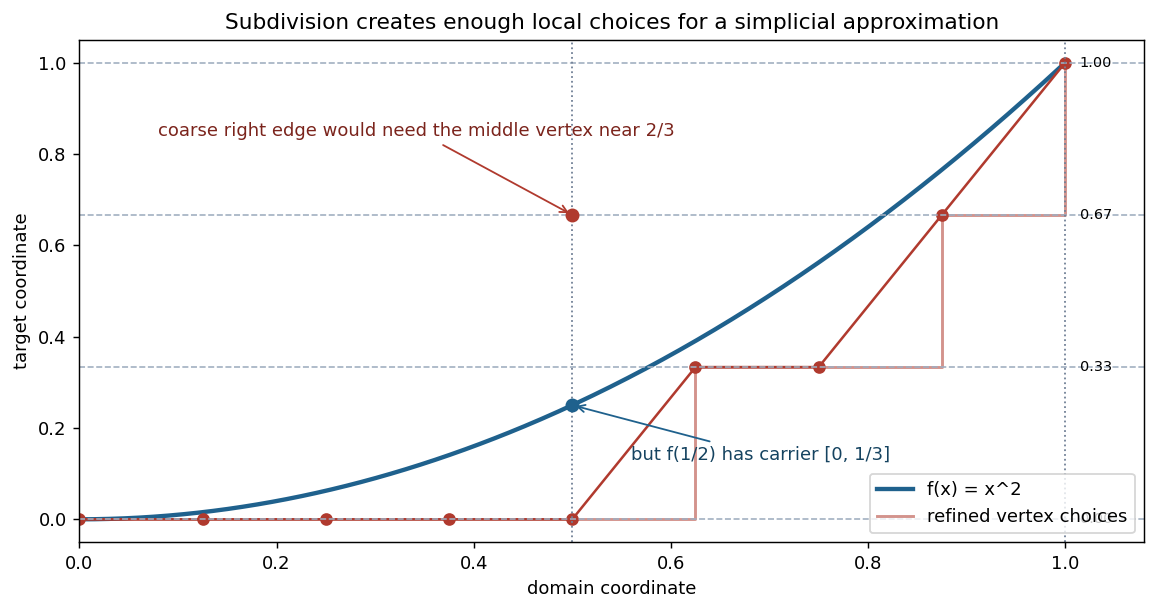

{'coarse_middle_carrier': (0.0, 0.3333333333333333),
 'coarse_possible': False,
 'refined_vertex_count': 9,
 'refined_edges_valid_in_target_complex': True,
 'refined_vertices_lie_in_point_carriers': True,
 'max_refined_domain_edge': 0.125}

In [5]:
def carrier_interval(value, target_vertices):
    target_vertices = np.array(target_vertices, dtype=float)
    if np.any(np.isclose(value, target_vertices)):
        hit = float(target_vertices[np.argmin(np.abs(value - target_vertices))])
        return (hit, hit)
    right = int(np.searchsorted(target_vertices, value, side="right"))
    return (float(target_vertices[right - 1]), float(target_vertices[right]))


def target_edge_valid(a, b, target_vertices):
    positions = {float(v): i for i, v in enumerate(target_vertices)}
    return abs(positions[float(a)] - positions[float(b)]) <= 1


def choose_refined_star_map(domain_vertices, target_vertices):
    choices = []
    star_ranges = {0.0: (0.0, 1 / 3), 1 / 3: (0.0, 2 / 3), 2 / 3: (1 / 3, 1.0), 1.0: (2 / 3, 1.0)}
    for idx, u in enumerate(domain_vertices):
        if idx == 0:
            lo, hi = domain_vertices[0], (domain_vertices[0] + domain_vertices[1]) / 2
        elif idx == len(domain_vertices) - 1:
            lo, hi = (domain_vertices[-2] + domain_vertices[-1]) / 2, domain_vertices[-1]
        else:
            lo = (domain_vertices[idx - 1] + domain_vertices[idx]) / 2
            hi = (domain_vertices[idx] + domain_vertices[idx + 1]) / 2
        image_lo = lo**2
        image_hi = hi**2
        possible = [vertex for vertex, (star_lo, star_hi) in star_ranges.items() if image_lo >= star_lo - 1e-12 and image_hi <= star_hi + 1e-12]
        if not possible:
            raise RuntimeError(f"No target star contains the image of the star around {u}")
        carrier = carrier_interval(u**2, target_vertices)
        carrier_choices = [v for v in possible if carrier[0] - 1e-12 <= v <= carrier[1] + 1e-12]
        choices.append(carrier_choices[0] if carrier_choices else possible[0])
    return np.array(choices, dtype=float)


target_vertices = np.array([0.0, 1 / 3, 2 / 3, 1.0])
coarse_vertices = np.array([0.0, 0.5, 1.0])
refined_vertices = np.linspace(0.0, 1.0, 9)
refined_values = choose_refined_star_map(refined_vertices, target_vertices)

middle_carrier = carrier_interval(0.5**2, target_vertices)
needed_for_right_edge = [2 / 3, 1.0]
coarse_possible = any(middle_carrier[0] <= value <= middle_carrier[1] for value in needed_for_right_edge)
refined_edges_valid = all(target_edge_valid(a, b, target_vertices) for a, b in zip(refined_values[:-1], refined_values[1:]))
refined_vertices_in_carriers = all(
    carrier_interval(u**2, target_vertices)[0] - 1e-12 <= s <= carrier_interval(u**2, target_vertices)[1] + 1e-12
    for u, s in zip(refined_vertices, refined_values)
)

x = np.linspace(0, 1, 400)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, x**2, color="#1f618d", linewidth=2.4, label="f(x) = x^2")
ax.step(refined_vertices, refined_values, where="post", color="#b03a2e", linewidth=1.6, alpha=0.55, label="refined vertex choices")
ax.plot(refined_vertices, refined_values, color="#b03a2e", marker="o", linewidth=1.4)
for v in target_vertices:
    ax.axhline(v, color="#a0aec0", linewidth=0.9, linestyle="--")
    ax.text(1.015, v, f"{v:.2f}", va="center", fontsize=8)
for u in coarse_vertices:
    ax.axvline(u, color="#718096", linewidth=1.0, linestyle=":")
ax.scatter([0.5], [0.25], color="#1f618d", s=45, zorder=5)
ax.scatter([0.5], [2 / 3], color="#b03a2e", s=45, zorder=5)
ax.annotate("coarse right edge would need the middle vertex near 2/3", xy=(0.5, 2 / 3), xytext=(0.08, 0.84), arrowprops={"arrowstyle": "->", "color": "#b03a2e"}, color="#7b241c")
ax.annotate("but f(1/2) has carrier [0, 1/3]", xy=(0.5, 0.25), xytext=(0.56, 0.13), arrowprops={"arrowstyle": "->", "color": "#1f618d"}, color="#154360")
ax.set_xlim(0, 1.08)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("domain coordinate")
ax.set_ylabel("target coordinate")
ax.set_title("Subdivision creates enough local choices for a simplicial approximation")
ax.legend(loc="lower right")
fig.tight_layout()
approx_path = record(FIG_DIR / "simplicial-approximation-carriers.png")
fig.savefig(approx_path, bbox_inches="tight")
plt.close(fig)

approx_check = {
    "coarse_middle_carrier": middle_carrier,
    "coarse_possible": bool(coarse_possible),
    "refined_vertex_count": int(len(refined_vertices)),
    "refined_edges_valid_in_target_complex": bool(refined_edges_valid),
    "refined_vertices_lie_in_point_carriers": bool(refined_vertices_in_carriers),
    "max_refined_domain_edge": float(np.diff(refined_vertices).max()),
}
write_json(approx_check, CHECK_DIR / "simplicial-approximation.json")
assert not coarse_possible
assert refined_edges_valid and refined_vertices_in_carriers
assert_artifact(approx_path, min_bytes=1024)
display_artifact(approx_path, width=780)
approx_check

The plot is not a proof of the theorem by itself. It is a computational model of the proof move: cover the target by open stars, pull that cover back along the continuous map, subdivide the domain until each domain star is small enough, then choose one target vertex for each domain vertex. The straight-line homotopy works because the chosen point and the original image lie in a common simplex.

## 4. Edge Paths, Triangle Moves, And Edge Groups

The edge group replaces arbitrary loops by loops that run along vertices and edges. Triangle relations are the key local move: if `u, v, w` span a triangle, then the two-edge path `u -> v -> w` can be replaced by the one-edge path `u -> w`.

For a connected graph with no filled triangles, there are no triangle relations. A maximal tree kills the tree edges, and every remaining edge contributes one free generator. The bouquet of two circles below is drawn as two triangular loops sharing a base vertex, but the interiors are deliberately absent.

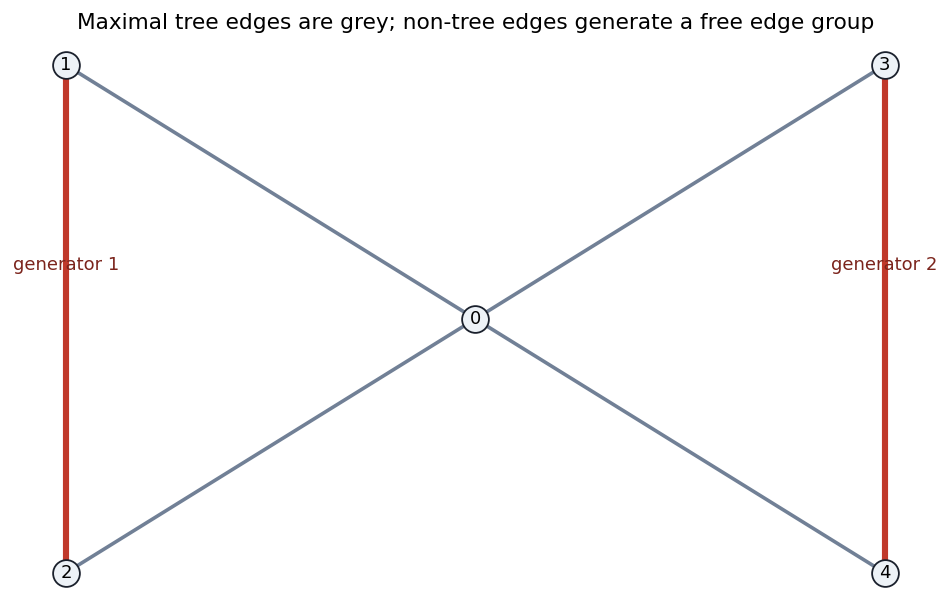

,space_or_complex,generators,relations,group_reading
0,bouquet of two circles,"x, y",none,free group of rank 2
1,torus quotient,"a, b",a b a^-1 b^-1,commuting pair
2,Klein bottle quotient,"t, u",t u^-1 t u,one conjugacy relation
3,projective plane quotient,a,a^2,order-two loop


In [6]:
def graph_cycle_rank(graph: nx.Graph) -> int:
    return graph.number_of_edges() - graph.number_of_nodes() + nx.number_connected_components(graph)


def reduce_by_triangle_moves(path, triangles, max_steps=50):
    triangles = {frozenset(t) for t in triangles}
    current = list(path)
    for _ in range(max_steps):
        changed = False
        compressed = [current[0]]
        for vertex in current[1:]:
            if vertex != compressed[-1]:
                compressed.append(vertex)
                changed = True
        current = compressed
        for i in range(len(current) - 2):
            triple = current[i : i + 3]
            if triple[0] == triple[2]:
                current = current[: i + 1] + current[i + 3 :]
                changed = True
                break
            if frozenset(triple) in triangles:
                current = current[: i + 1] + current[i + 2 :]
                changed = True
                break
        if len(current) > 1 and current[0] == current[-1] and len(current) == 2:
            current = [current[0]]
            changed = True
        if not changed:
            return current
    return current


bouquet_edges = [(0, 1), (1, 2), (2, 0), (0, 3), (3, 4), (4, 0)]
bouquet = nx.Graph()
bouquet.add_edges_from(bouquet_edges)
tree_edges = set(tuple(sorted(edge)) for edge in nx.bfs_tree(bouquet, 0).edges())
non_tree_edges = [edge for edge in bouquet_edges if tuple(sorted(edge)) not in tree_edges]

positions = {0: (0, 0), 1: (-1.0, 0.62), 2: (-1.0, -0.62), 3: (1.0, 0.62), 4: (1.0, -0.62)}
fig, ax = plt.subplots(figsize=(7.8, 4.8))
for edge in bouquet_edges:
    ordered = tuple(sorted(edge))
    color = "#718096" if ordered in tree_edges else "#c0392b"
    width = 2.0 if ordered in tree_edges else 3.4
    ax.plot([positions[edge[0]][0], positions[edge[1]][0]], [positions[edge[0]][1], positions[edge[1]][1]], color=color, linewidth=width)
for node, point in positions.items():
    ax.scatter(*point, s=220, color="#edf2f7", edgecolor="#1a202c", zorder=3)
    ax.text(point[0], point[1], str(node), ha="center", va="center", zorder=4)
for idx, edge in enumerate(non_tree_edges, start=1):
    midpoint = (np.array(positions[edge[0]]) + np.array(positions[edge[1]])) / 2
    ax.text(midpoint[0], midpoint[1] + 0.12, f"generator {idx}", color="#7b241c", ha="center")
ax.set_title("Maximal tree edges are grey; non-tree edges generate a free edge group")
ax.set_aspect("equal")
ax.axis("off")
fig.tight_layout()
edge_path = record(FIG_DIR / "edge-loop-complex.png")
fig.savefig(edge_path, bbox_inches="tight")
plt.close(fig)

filled_triangle_loop = [0, 1, 2, 0]
unfilled_triangle_loop = [0, 1, 2, 0]
edge_group_check = {
    "bouquet_vertices": bouquet.number_of_nodes(),
    "bouquet_edges": bouquet.number_of_edges(),
    "maximal_tree_edges": len(tree_edges),
    "free_rank_E_minus_V_plus_1": graph_cycle_rank(bouquet),
    "non_tree_edges": [list(edge) for edge in non_tree_edges],
    "filled_triangle_loop_reduces_to": reduce_by_triangle_moves(filled_triangle_loop, [(0, 1, 2)]),
    "unfilled_triangle_loop_reduces_to": reduce_by_triangle_moves(unfilled_triangle_loop, []),
}
write_json(edge_group_check, CHECK_DIR / "edge-group-checks.json")

presentation_df = pd.DataFrame([
    {"space_or_complex": "bouquet of two circles", "generators": "x, y", "relations": "none", "group_reading": "free group of rank 2"},
    {"space_or_complex": "torus quotient", "generators": "a, b", "relations": "a b a^-1 b^-1", "group_reading": "commuting pair"},
    {"space_or_complex": "Klein bottle quotient", "generators": "t, u", "relations": "t u^-1 t u", "group_reading": "one conjugacy relation"},
    {"space_or_complex": "projective plane quotient", "generators": "a", "relations": "a^2", "group_reading": "order-two loop"},
])
write_csv(presentation_df, TABLE_DIR / "edge-group-presentations.csv")
assert edge_group_check["free_rank_E_minus_V_plus_1"] == 2
assert edge_group_check["filled_triangle_loop_reduces_to"] == [0]
assert edge_group_check["unfilled_triangle_loop_reduces_to"] == [0, 1, 2, 0]
assert_artifact(edge_path, min_bytes=1024)
display_artifact(edge_path, width=720)
presentation_df

The edge group theorem says this edge-loop calculation agrees with the ordinary fundamental group of the polyhedron. The value is that the calculation becomes finite and local: choose a tree, list the remaining edges, and let triangles impose relations.

The table records standard quotient presentations because they are the surface calculations this chapter sets up. A full simplification of a large triangulation can be tedious, which is exactly why the theorem is useful: it turns the problem into generators and relations rather than continuous loop homotopies.

## 5. Triangulated Surfaces And Quotient Spaces

A quotient polygon is not automatically a simplicial complex, but it tells us what a compatible triangulation must respect. The torus and Klein bottle both have one vertex, two edge classes, and one face in their cell decompositions, so their Euler characteristic is 0. The projective plane has one vertex, one edge class, and one face, so its Euler characteristic is 1.

For a directly inspectable triangulated surface, the code also builds a periodic triangular grid and embeds it as a torus mesh in 3-space. The mesh is not the definition of the torus, but it is a useful checkable realization of the quotient data.

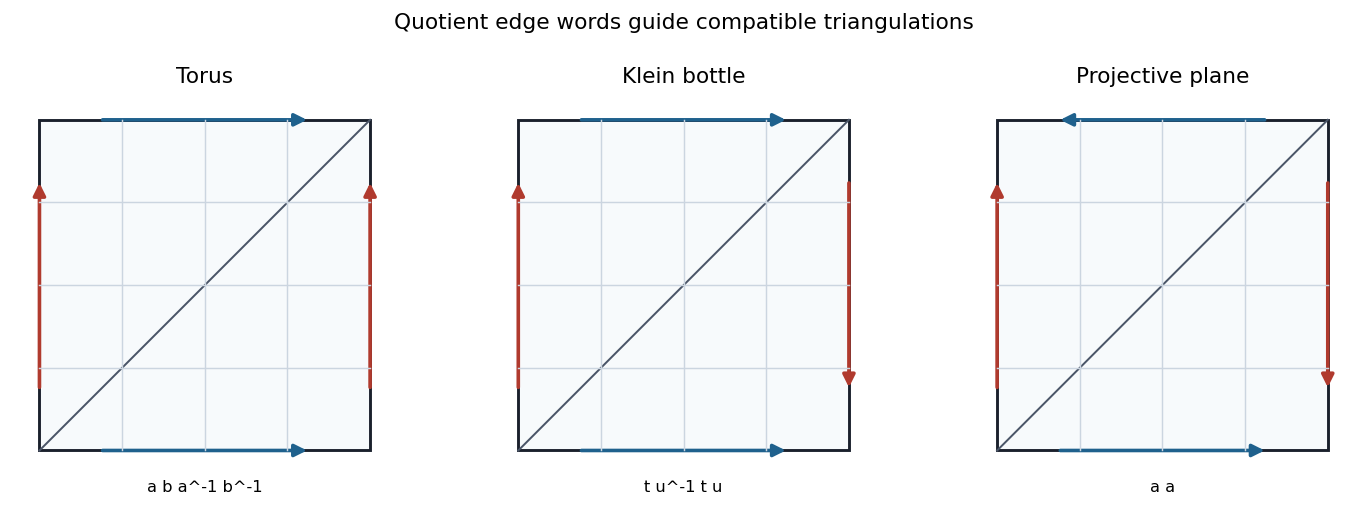

,quotient_model,cell_vertices,cell_edges,cell_faces,chi,edge_word
0,torus,1,2,1,0,a b a^-1 b^-1
1,Klein bottle,1,2,1,0,t u^-1 t u
2,projective plane,1,1,1,1,a^2


In [7]:
def arrow(ax, start, end, color="#2c3e50"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, linewidth=2.0, color=color))


def draw_quotient_panel(ax, title, horizontal_same=True, vertical_same=True, relation=""):
    square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
    ax.add_patch(Polygon(square, closed=True, facecolor="#f7fafc", edgecolor="#1a202c", linewidth=1.6))
    ax.plot([0, 1], [0, 1], color="#4a5568", linewidth=1.1)
    for t in np.linspace(0.25, 0.75, 3):
        ax.plot([t, t], [0, 1], color="#cbd5e0", linewidth=0.8)
        ax.plot([0, 1], [t, t], color="#cbd5e0", linewidth=0.8)
    if horizontal_same:
        arrow(ax, (0.18, 0), (0.82, 0), "#1f618d")
        arrow(ax, (0.18, 1), (0.82, 1), "#1f618d")
    else:
        arrow(ax, (0.18, 0), (0.82, 0), "#1f618d")
        arrow(ax, (0.82, 1), (0.18, 1), "#1f618d")
    if vertical_same:
        arrow(ax, (0, 0.18), (0, 0.82), "#b03a2e")
        arrow(ax, (1, 0.18), (1, 0.82), "#b03a2e")
    else:
        arrow(ax, (0, 0.18), (0, 0.82), "#b03a2e")
        arrow(ax, (1, 0.82), (1, 0.18), "#b03a2e")
    ax.text(0.5, -0.11, relation, ha="center", va="center", fontsize=9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.18, 1.08)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.9))
draw_quotient_panel(axes[0], "Torus", horizontal_same=True, vertical_same=True, relation="a b a^-1 b^-1")
draw_quotient_panel(axes[1], "Klein bottle", horizontal_same=True, vertical_same=False, relation="t u^-1 t u")
draw_quotient_panel(axes[2], "Projective plane", horizontal_same=False, vertical_same=False, relation="a a")
fig.suptitle("Quotient edge words guide compatible triangulations", y=1.02)
fig.tight_layout()
quotient_path = record(FIG_DIR / "quotient-surface-triangulations.png")
fig.savefig(quotient_path, bbox_inches="tight")
plt.close(fig)

quotient_df = pd.DataFrame([
    {"quotient_model": "torus", "cell_vertices": 1, "cell_edges": 2, "cell_faces": 1, "chi": 0, "edge_word": "a b a^-1 b^-1"},
    {"quotient_model": "Klein bottle", "cell_vertices": 1, "cell_edges": 2, "cell_faces": 1, "chi": 0, "edge_word": "t u^-1 t u"},
    {"quotient_model": "projective plane", "cell_vertices": 1, "cell_edges": 1, "cell_faces": 1, "chi": 1, "edge_word": "a^2"},
])
write_csv(quotient_df, TABLE_DIR / "quotient-surface-cell-counts.csv")
assert set(quotient_df["chi"]) == {0, 1}
assert_artifact(quotient_path, min_bytes=1024)
display_artifact(quotient_path, width=900)
quotient_df

In [8]:
def torus_trimesh(nx=12, ny=8, major=2.0, minor=0.62):
    vertices = []
    for i in range(nx):
        u = 2 * np.pi * i / nx
        for j in range(ny):
            v = 2 * np.pi * j / ny
            vertices.append(((major + minor * np.cos(v)) * np.cos(u), (major + minor * np.cos(v)) * np.sin(u), minor * np.sin(v)))

    def idx(i, j):
        return (i % nx) * ny + (j % ny)

    faces = []
    for i in range(nx):
        for j in range(ny):
            faces.append((idx(i, j), idx(i + 1, j), idx(i + 1, j + 1)))
            faces.append((idx(i, j), idx(i + 1, j + 1), idx(i, j + 1)))
    return trimesh.Trimesh(vertices=np.array(vertices), faces=np.array(faces), process=False)


torus_mesh = torus_trimesh(12, 8)
mesh_fig = go.Figure(data=[go.Mesh3d(
    x=torus_mesh.vertices[:, 0], y=torus_mesh.vertices[:, 1], z=torus_mesh.vertices[:, 2],
    i=torus_mesh.faces[:, 0], j=torus_mesh.faces[:, 1], k=torus_mesh.faces[:, 2],
    intensity=torus_mesh.vertices[:, 2], colorscale="Viridis", opacity=0.92, flatshading=True, name="triangulated torus")])
mesh_fig.update_layout(
    title="Periodic triangular grid realized as a torus mesh",
    scene={"aspectmode": "data", "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False}},
    margin={"l": 0, "r": 0, "t": 45, "b": 0},
)
torus_html = record(HTML_DIR / "triangulated-torus-quotient-mesh.html")
mesh_fig.write_html(torus_html, include_plotlyjs="cdn", full_html=True)

mesh_check = {
    "vertices": int(len(torus_mesh.vertices)),
    "unique_edges": int(len(torus_mesh.edges_unique)),
    "faces": int(len(torus_mesh.faces)),
    "euler_number_trimesh": int(torus_mesh.euler_number),
    "is_watertight": bool(torus_mesh.is_watertight),
    "body_count": int(torus_mesh.body_count),
    "max_edge_length": float(torus_mesh.edges_unique_length.max()),
}
write_json(mesh_check, CHECK_DIR / "torus-mesh-invariants.json")
assert mesh_check["euler_number_trimesh"] == 0
assert mesh_check["is_watertight"]
assert_artifact(torus_html, min_bytes=1024)
display_artifact(torus_html, width="100%", height=520)
mesh_check

{'vertices': 96,
 'unique_edges': 288,
 'faces': 192,
 'euler_number_trimesh': 0,
 'is_watertight': True,
 'body_count': 1,
 'max_edge_length': 1.3917625575482433}

The 3D mesh gives a separate geometric sanity check: `V - E + F = 0`, the mesh is watertight, and the underlying complex has the Betti pattern of a torus. This is exactly the reason triangulated models are useful in topology: the surface can be rendered, refined, and checked without changing its topological type.

## 6. Orbit Triangulations And Infinite Complexes

The orbit-space construction starts with a simplicial action: group elements send simplexes linearly onto simplexes. The vertex scheme of the quotient records orbits of vertices and which orbit sets come from original simplexes. Armstrong's chapter then explains why a second barycentric subdivision removes the main ambiguity: vertices inside one small simplex no longer collapse into the same orbit in the bad way.

The last section relaxes finiteness. Infinite complexes are allowed only when the topology from the ambient Euclidean space agrees with the topology from gluing simplexes. A practical local test is local finiteness: every vertex should meet only finitely many simplexes, and every bounded inspection window should see a finite pattern.

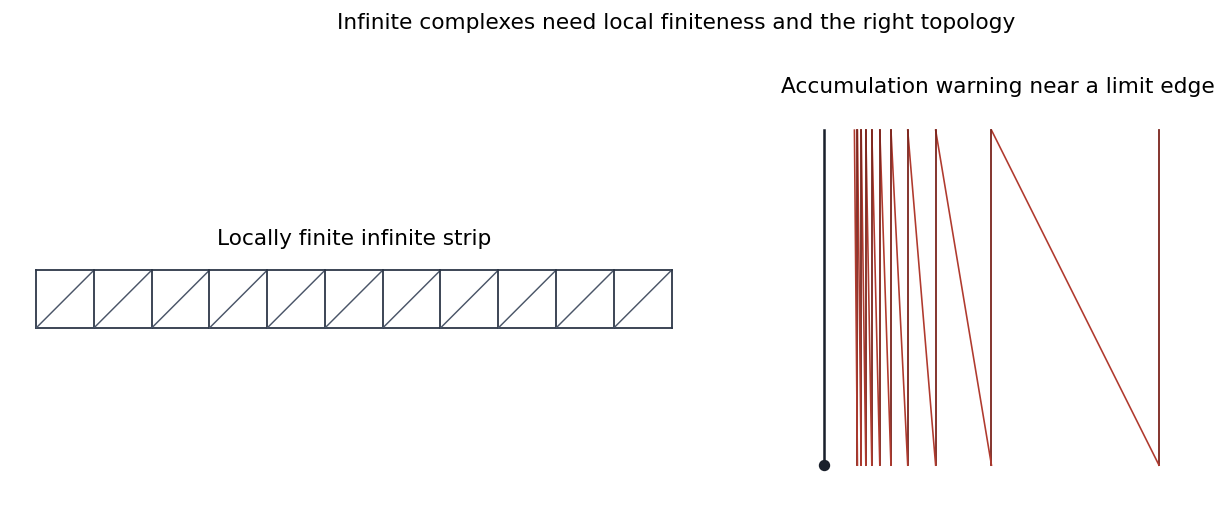

{'strip_window_triangles_drawn': 22,
 'strip_vertex_star_bound_in_interior': 6,
 'accumulation_panel_segments_drawn': 20,
 'lesson': 'local finiteness prevents infinitely many unrelated simplexes from piling up at one vertex or limit point'}

In [9]:
def draw_infinite_complex_samples(path: Path, n=5):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
    ax = axes[0]
    for i in range(-n, n + 1):
        ax.plot([i, i + 1], [0, 0], color="#2d3748", linewidth=1.0)
        ax.plot([i, i + 1], [1, 1], color="#2d3748", linewidth=1.0)
        ax.plot([i, i], [0, 1], color="#2d3748", linewidth=1.0)
        ax.plot([i, i + 1], [0, 1], color="#4a5568", linewidth=0.8)
    ax.plot([n + 1, n + 1], [0, 1], color="#2d3748", linewidth=1.0)
    ax.set_title("Locally finite infinite strip")
    ax.set_aspect("equal")
    ax.set_xlim(-n - 0.4, n + 1.4)
    ax.set_ylim(-0.2, 1.25)
    ax.axis("off")

    ax = axes[1]
    for k in range(1, n + 6):
        x0 = 1 / k
        x1 = 1 / (k + 1)
        ax.plot([x0, x0], [0, 1], color="#7b241c", linewidth=1.0)
        ax.plot([x0, x1], [0, 1], color="#b03a2e", linewidth=0.9)
    ax.plot([0, 0], [0, 1], color="#1a202c", linewidth=1.4)
    ax.scatter([0], [0], color="#1a202c", s=28)
    ax.set_title("Accumulation warning near a limit edge")
    ax.set_aspect("equal")
    ax.set_xlim(-0.04, 1.08)
    ax.set_ylim(-0.08, 1.08)
    ax.axis("off")
    fig.suptitle("Infinite complexes need local finiteness and the right topology", y=1.01)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return record(path)


infinite_path = draw_infinite_complex_samples(FIG_DIR / "infinite-complex-local-finiteness.png")
infinite_check = {
    "strip_window_triangles_drawn": int(2 * (2 * 5 + 1)),
    "strip_vertex_star_bound_in_interior": 6,
    "accumulation_panel_segments_drawn": 2 * (5 + 5),
    "lesson": "local finiteness prevents infinitely many unrelated simplexes from piling up at one vertex or limit point",
}
write_json(infinite_check, CHECK_DIR / "infinite-complex-local-finiteness.json")
assert infinite_check["strip_vertex_star_bound_in_interior"] == 6
assert_artifact(infinite_path, min_bytes=1024)
display_artifact(infinite_path, width=840)
infinite_check

## Applied Lab: Refine A Quotient Triangulation And Watch The Invariants

In this lab, the object is a torus built from a periodic triangular grid. Increase the grid size and rerun the cell. The counts `V`, `E`, and `F` grow quickly, while `chi`, Betti numbers, and watertightness stay fixed. That is the computational version of the chapter's main habit: triangulations can be changed to make a construction easier, but the topological invariants should remain stable.

In [10]:
def torus_complex_and_mesh(n):
    faces = closure(periodic_torus_facets(n, n))
    mesh = torus_trimesh(n, n)
    return faces, mesh

lab_rows = []
for n in [3, 4, 5, 6, 7]:
    faces, mesh = torus_complex_and_mesh(n)
    fv = f_vector(faces)
    lab_rows.append({
        "periodic_grid": f"{n}x{n}",
        "vertices": fv[0],
        "edges": fv[1],
        "triangles": fv[2],
        "chi_from_complex": int(euler_characteristic(faces)),
        "betti_Q": str(betti_over_q(faces, max_dim=2)),
        "trimesh_euler": int(mesh.euler_number),
        "watertight_mesh": bool(mesh.is_watertight),
        "max_embedded_edge_length": float(mesh.edges_unique_length.max()),
    })

lab_df = pd.DataFrame(lab_rows)
write_csv(lab_df, TABLE_DIR / "applied-lab-torus-refinement.csv")
lab_check = {
    "all_chi_zero": bool((lab_df["chi_from_complex"] == 0).all()),
    "all_betti_torus": bool((lab_df["betti_Q"] == str([1, 2, 1])).all()),
    "all_meshes_watertight": bool(lab_df["watertight_mesh"].all()),
    "edge_lengths_decrease_from_first_to_last": bool(lab_df["max_embedded_edge_length"].iloc[-1] < lab_df["max_embedded_edge_length"].iloc[0]),
}
write_json(lab_check, CHECK_DIR / "applied-lab-torus-refinement.json")
assert lab_check["all_chi_zero"]
assert lab_check["all_betti_torus"]
assert lab_check["all_meshes_watertight"]
lab_df

,periodic_grid,vertices,edges,triangles,chi_from_complex,betti_Q,trimesh_euler,watertight_mesh,max_embedded_edge_length
0,3x3,9,27,18,0,"[1, 2, 1]",0,True,4.537973
1,4x4,16,48,32,0,"[1, 2, 1]",0,True,3.705240
2,5x5,25,75,50,0,"[1, 2, 1]",0,True,3.079995
3,6x6,36,108,72,0,"[1, 2, 1]",0,True,2.620000
4,7x7,49,147,98,0,"[1, 2, 1]",0,True,2.273551


## Final Sanity Checks

The final checks assert the chapter's core computational claims: boundary maps compose to zero, subdivision preserves Euler characteristic while shrinking mesh, the torus has the expected invariant data, generated artifacts exist and are nonempty, and the applied lab preserves topology under refinement.

In [11]:
expected_artifacts = [
    FIG_DIR / "simplicial-complex-incidence.png",
    FIG_DIR / "concept-dependency-map.png",
    FIG_DIR / "barycentric-subdivision-triangle.png",
    FIG_DIR / "simplicial-approximation-carriers.png",
    FIG_DIR / "edge-loop-complex.png",
    FIG_DIR / "quotient-surface-triangulations.png",
    FIG_DIR / "infinite-complex-local-finiteness.png",
    HTML_DIR / "triangulated-torus-quotient-mesh.html",
    TABLE_DIR / "simplicial-invariants.csv",
    TABLE_DIR / "edge-group-presentations.csv",
    TABLE_DIR / "quotient-surface-cell-counts.csv",
    TABLE_DIR / "applied-lab-torus-refinement.csv",
    CHECK_DIR / "simplicial-invariants.json",
    CHECK_DIR / "barycentric-subdivision.json",
    CHECK_DIR / "simplicial-approximation.json",
    CHECK_DIR / "edge-group-checks.json",
    CHECK_DIR / "torus-mesh-invariants.json",
    CHECK_DIR / "infinite-complex-local-finiteness.json",
    CHECK_DIR / "applied-lab-torus-refinement.json",
]

for path in expected_artifacts:
    assert_artifact(path, min_bytes=64 if path.suffix in {".json", ".csv"} else 1024)

assert all(boundary_square_zero(triangle_disk).values())
assert all(boundary_square_zero(tetrahedron_sphere).values())
assert all(boundary_square_zero(torus_4x4).values())
assert euler_characteristic(triangle_disk) == euler_characteristic(subdivision_faces) == 1
assert bary_check["mesh_ratio"] <= bary_check["expected_ratio_bound_for_dimension_2"] + 1e-12
assert not approx_check["coarse_possible"]
assert approx_check["refined_edges_valid_in_target_complex"]
assert edge_group_check["free_rank_E_minus_V_plus_1"] == 2
assert betti_over_q(torus_4x4, max_dim=2) == [1, 2, 1]
assert mesh_check["euler_number_trimesh"] == 0 and mesh_check["is_watertight"]
assert lab_check["all_chi_zero"] and lab_check["all_betti_torus"] and lab_check["all_meshes_watertight"]

sanity_summary = {
    "source_span": "Armstrong Basic Topology printed pp. 119-148; PDF pages 129-158",
    "core_identities": {
        "boundary_squared_zero_triangle": boundary_square_zero(triangle_disk),
        "boundary_squared_zero_sphere": boundary_square_zero(tetrahedron_sphere),
        "boundary_squared_zero_torus": boundary_square_zero(torus_4x4),
        "barycentric_euler_preserved": True,
        "barycentric_mesh_ratio": bary_check["mesh_ratio"],
        "torus_betti_Q": betti_over_q(torus_4x4, max_dim=2),
        "torus_mesh_euler": mesh_check["euler_number_trimesh"],
    },
    "artifact_count": len(expected_artifacts) + 1,
    "artifacts": [rel(path) for path in expected_artifacts] + [rel(CHECK_DIR / "sanity-checks.json")],
}
write_json(sanity_summary, CHECK_DIR / "sanity-checks.json")
assert_artifact(CHECK_DIR / "sanity-checks.json", min_bytes=256)
sanity_summary

{'source_span': 'Armstrong Basic Topology printed pp. 119-148; PDF pages 129-158',
 'core_identities': {'boundary_squared_zero_triangle': {'d1_after_d2': True},
  'boundary_squared_zero_sphere': {'d1_after_d2': True},
  'boundary_squared_zero_torus': {'d1_after_d2': True},
  'barycentric_euler_preserved': True,
  'barycentric_mesh_ratio': 0.5773502691896257,
  'torus_betti_Q': [1, 2, 1],
  'torus_mesh_euler': 0},
 'artifact_count': 20,
 'artifacts': ['artifacts/chapter-06/figures/simplicial-complex-incidence.png',
  'artifacts/chapter-06/figures/concept-dependency-map.png',
  'artifacts/chapter-06/figures/barycentric-subdivision-triangle.png',
  'artifacts/chapter-06/figures/simplicial-approximation-carriers.png',
  'artifacts/chapter-06/figures/edge-loop-complex.png',
  'artifacts/chapter-06/figures/quotient-surface-triangulations.png',
  'artifacts/chapter-06/figures/infinite-complex-local-finiteness.png',
  'artifacts/chapter-06/html/triangulated-torus-quotient-mesh.html',
  'artifa

## Takeaways

- A triangulation turns a space into finite incidence data when the space is compact and locally simple enough.
- Barycentric subdivision is a proof tool: it refines by face chains, preserves the polyhedron, and shrinks mesh.
- Simplicial approximation replaces continuous maps by vertex data after enough subdivision, with homotopy protected by carriers.
- Edge groups make fundamental-group calculations combinatorial: tree edges vanish, remaining edges generate, and triangles impose relations.
- Quotient spaces need compatible triangulations; barycentric subdivision and vertex schemes explain how orbit spaces become complexes.
- Infinite complexes are useful only with local finiteness and the right topology, so the gluing model and ambient model agree.